# 第 14 章　序列資料：心電圖、一維卷積與資料洩漏 — 實作 Notebook

「醫學生的機器學習入門」深度學習篇第 14 章配套程式（網站：<https://med-study-rpg.com/ml/chapters/14-ecg/>）。建議在 **Google Colab** 執行（「執行階段 → 全部執行」）；本機 Jupyter 需安裝 `tensorflow` 與 `keras`。

本 notebook 做一個實驗：**同一個一維卷積網路（1D-CNN），只改變「訓練集與測試集怎麼切」，成績會差多少？**

1. 從 PhysioNet 官方下載 MIT-BIH Arrhythmia Database（77 MB 的 zip），自己讀出心電圖訊號與心跳標註
2. 以 R 峰為中心切出一個個心跳，對應到 AAMI 的心跳類別
3. **切法 A：把所有心跳打散後隨機切**；**切法 B：依受試者切**（同一個人的心跳只會在訓練或測試其中一邊）
4. 同一個 1D-CNN 分別在兩種切法下訓練與測試，比較準確率、macro-F1 與各類別敏感度

時間：本機筆電 CPU 約 2 分鐘（不含下載）。Colab 下載通常很快；第 5 節（重複另外兩折）在 Colab 免費 CPU 上較久，**建議開 GPU，也可以跳過**。

資料：MIT-BIH Arrhythmia Database（Moody & Mark 2001；PhysioNet），授權 Open Data Commons Attribution License v1.0（ODC-By）。本 notebook 的結果僅供學習，不構成臨床建議。

## 0. 環境檢查
印出套件版本並固定隨機種子。Keras 要在 `import` 之前用環境變數指定後端（backend）。沒有 Keras 的環境會跳過訓練段落。

In [1]:
import os
import time
import zipfile
import hashlib
import urllib.request

import numpy as np
import pandas as pd
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import f1_score, recall_score, confusion_matrix

print("numpy", np.__version__, "| pandas", pd.__version__, "| scipy", scipy.__version__,
      "| scikit-learn", sklearn.__version__, "| matplotlib", matplotlib.__version__)
RS = 42
T_START = time.time()

os.environ["KERAS_BACKEND"] = "tensorflow"   # must be set before importing keras
try:
    import keras
    keras.utils.set_random_seed(RS)          # results may still differ slightly across hardware
    print("keras", keras.__version__, "| backend:", keras.backend.backend())
except ImportError:
    keras = None
    print("Keras is not installed in this environment -> training sections will be skipped.")
    print("Run this notebook on Google Colab, or `pip install tensorflow keras` locally.")

numpy 2.1.3 | pandas 2.2.3 | scipy 1.16.3 | scikit-learn 1.6.1 | matplotlib 3.10.0


keras 3.13.2 | backend: tensorflow


## 1. 從官方來源下載原始資料

MIT-BIH Arrhythmia Database 有 48 段、每段 30 分鐘的雙導程 Holter 心電圖，取樣率 360 Hz，來自 47 位受試者（**record 201 與 202 是同一個人**），每個心跳都由心臟科醫師標註過。

下載策略（依序嘗試，前一個失敗才用下一個）：

- **方案 A**：PhysioNet 官方整包 zip（77 MB）。下載到 `data/mitdb.zip`，已經下載過就直接用。（本檔存著的輸出是用先前從 PhysioNet 下載、已比對官方 SHA256 的 zip 執行的，所以顯示 no download needed；你在 Colab 執行時會實際下載。）
- **方案 B**：從 PhysioNet 官方網址逐檔下載需要的 132 個檔案（44 段 × 3 種檔）。
- **方案 C**：Hugging Face 上的第三方公開鏡像（`epr-labs/mit-bih-arrhythmia-database`，同樣是 ODC-By 的原始訊號），只在官方來源都失敗時使用。

依 AAMI 慣例，排除 4 段裝有節律器（pacemaker）的紀錄（102、104、107、217），剩下 44 段、43 位受試者。

In [2]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
ZIP_URL = "https://physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip"
FILE_URL = "https://physionet.org/files/mitdb/1.0.0/"
HF_URL = ("https://huggingface.co/datasets/epr-labs/mit-bih-arrhythmia-database/"
          "resolve/main/data/train-00000-of-00001.parquet")
ZIP_PATH = os.path.join(DATA_DIR, "mitdb.zip")

# 44 non-paced records (AAMI convention drops paced records 102, 104, 107, 217)
RECORDS = '''100 101 103 105 106 108 109 111 112 113 114 115 116 117 118 119 121 122 123 124
200 201 202 203 205 207 208 209 210 212 213 214 215 219 220 221 222 223 228 230 231 232 233 234'''.split()
SUBJECT = {r: ("201" if r == "202" else r) for r in RECORDS}   # records 201 and 202 = same person


def plan_a_zip():
    """Official PhysioNet zip (77 MB). Returns a function name -> file bytes."""
    if not (os.path.exists(ZIP_PATH) and zipfile.is_zipfile(ZIP_PATH)):   # skip half-downloaded files
        print("downloading the official zip (77 MB) from physionet.org ...")
        urllib.request.urlretrieve(ZIP_URL, ZIP_PATH + ".part")
        os.replace(ZIP_PATH + ".part", ZIP_PATH)
    else:
        print("found", ZIP_PATH, "-> no download needed")
    z = zipfile.ZipFile(ZIP_PATH)
    root = z.namelist()[0].split("/")[0]
    # integrity check: the zip ships its own SHA256SUMS.txt
    sums = dict(line.split()[::-1] for line in z.read(f"{root}/SHA256SUMS.txt").decode().splitlines() if line)
    for r in RECORDS:
        for ext in (".hea", ".dat", ".atr"):
            assert hashlib.sha256(z.read(f"{root}/{r}{ext}")).hexdigest() == sums[r + ext], r + ext
    print("SHA-256 of all", 3 * len(RECORDS), "files match SHA256SUMS.txt")
    return lambda name: z.read(f"{root}/{name}")


def plan_b_files():
    """Official PhysioNet per-file download (132 small requests)."""
    folder = os.path.join(DATA_DIR, "mitdb_files")
    os.makedirs(folder, exist_ok=True)
    for r in RECORDS:
        for ext in (".hea", ".dat", ".atr"):
            path = os.path.join(folder, r + ext)
            if not os.path.exists(path):
                urllib.request.urlretrieve(FILE_URL + r + ext, path + ".part")
                os.replace(path + ".part", path)   # never reuse a half-downloaded file
    print("downloaded", 3 * len(RECORDS), "files from", FILE_URL)
    return lambda name: open(os.path.join(folder, name), "rb").read()

WFDB 格式的檔案有三種：`.hea` 是文字標頭（取樣率、導程名稱、放大倍率），`.dat` 是訊號（每 3 個位元組存 2 個 12 位元的樣本，稱為 format 212），`.atr` 是心跳標註（每個心跳的位置與符號）。

一般會用 `pip install wfdb` 套件讀取；為了在 Colab 免安裝，這裡用 NumPy 寫一個小讀檔器。**你不需要看懂這一格**，只要知道它和 `wfdb.rdrecord`／`wfdb.rdann` 讀出來的東西一樣（我們在 48 段紀錄上逐點比對過）。

In [3]:
BEAT_CODES = {1: "N", 2: "L", 3: "R", 4: "a", 5: "V", 6: "F", 7: "J", 8: "A", 9: "S",
              10: "E", 11: "j", 12: "/", 13: "Q", 34: "e", 38: "f"}   # MIT annotation codes


def read_header(text):
    lines = [l for l in text.splitlines() if l.strip() and not l.startswith("#")]
    n_sig, fs = int(lines[0].split()[1]), float(lines[0].split()[2])
    sigs = []
    for l in lines[1:1 + n_sig]:
        p = l.split()
        sigs.append({"gain": float(p[2].split("/")[0].split("(")[0]), "adc_zero": int(p[4]), "name": p[-1]})
    return n_sig, fs, sigs


def read_212(raw, n_sig):
    b = np.frombuffer(raw, dtype=np.uint8).reshape(-1, 3).astype(np.int16)
    s0 = b[:, 0] | ((b[:, 1] & 0x0F) << 8)          # 12-bit sample 1
    s1 = b[:, 2] | ((b[:, 1] & 0xF0) << 4)          # 12-bit sample 2
    d = np.stack([s0, s1], axis=1).reshape(-1, n_sig)
    d[d > 2047] -= 4096                             # two's complement
    return d


def read_atr(raw):
    w = np.frombuffer(raw, dtype="<u2")
    samples, symbols, t, i = [], [], 0, 0
    while i < len(w):
        code, inc = int(w[i]) >> 10, int(w[i]) & 0x3FF
        if code == 0 and inc == 0:                  # end of file
            break
        if code == 59:                              # SKIP: long time jump
            t += int(np.int32((int(w[i + 1]) << 16) | int(w[i + 2])))
            i += 3
        elif code == 63:                            # AUX: text attached to the previous label
            i += 1 + (inc + 1) // 2
        elif code in (60, 61, 62):                  # NUM / SUB / CHN fields
            i += 1
        else:
            t += inc
            samples.append(t)
            symbols.append(BEAT_CODES.get(code, "?"))   # "?" = non-beat label (rhythm, noise...)
            i += 1
    return np.array(samples), np.array(symbols)


def read_records(get_bytes):
    """Return {record: (fs, MLII signal in mV, annotation samples, annotation symbols)}."""
    out = {}
    for r in RECORDS:
        n_sig, fs, sigs = read_header(get_bytes(r + ".hea").decode())
        k = [s["name"] for s in sigs].index("MLII")       # record 114 stores MLII as the 2nd lead
        dig = read_212(get_bytes(r + ".dat"), n_sig)[:, k]
        samp, sym = read_atr(get_bytes(r + ".atr"))
        out[r] = (fs, (dig - sigs[k]["adc_zero"]) / sigs[k]["gain"], samp, sym)
    return out


def plan_c_mirror():
    """Fallback: third-party Hugging Face mirror of the same raw files (ODC-By); needs pyarrow."""
    import json
    path = os.path.join(DATA_DIR, "mitdb_hf.parquet")
    if not os.path.exists(path):
        urllib.request.urlretrieve(HF_URL, path)
    out = {}
    for _, row in pd.read_parquet(path).iterrows():
        h = json.loads(row["header"])
        if h["record_name"] in RECORDS:
            k = h["sig_name"].index("MLII")
            out[h["record_name"]] = (float(h["fs"]), np.stack(row["signals"])[:, k].astype(float),
                                     np.asarray(row["annotation_sample"]), np.asarray(row["annotation_symbol"]))
    print("loaded from the Hugging Face mirror")
    return out


t0 = time.time()
records = None
for plan in (lambda: read_records(plan_a_zip()), lambda: read_records(plan_b_files()), plan_c_mirror):
    try:
        records = plan()
        break
    except Exception as e:
        print("download plan failed:", repr(e)[:200], "-> trying the next one")
assert records is not None and len(records) == len(RECORDS), (
    "All download plans failed. Check your internet connection, or download the zip manually from "
    "https://physionet.org/content/mitdb/1.0.0/ and put it at data/mitdb.zip")
T_LOAD = time.time() - t0
print(f"{len(records)} records loaded in {T_LOAD:.1f} s (download + reading)")

found data/mitdb.zip -> no download needed


SHA-256 of all 132 files match SHA256SUMS.txt


44 records loaded in 1.7 s (download + reading)


## 2. 看一段心電圖

先看 record 208 的其中 6 秒（MLII 導程）。每個心跳上方的字母是標註：`N` 正常、`V` 心室早期收縮（premature ventricular contraction, PVC）、`F` 正常與心室的融合波（fusion beat）。標註的位置就是 R 峰。

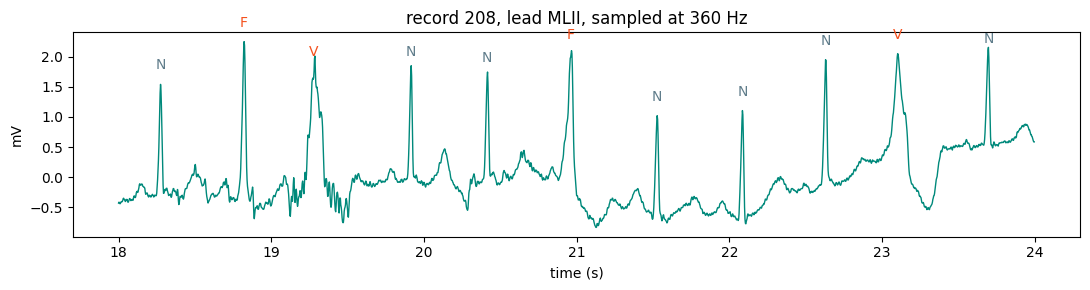

samples per second: 360.0 | total samples in this record: 650000 (= 30.1 minutes)


In [4]:
fs, sig, samp, sym = records["208"]
start, length = int(18.0 * fs), int(6 * fs)
seg_t = np.arange(start, start + length) / fs
m = (samp >= start) & (samp < start + length) & (sym != "?")

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(seg_t, sig[start:start + length], color="#00897B", lw=1)
for s, a in zip(samp[m], sym[m]):
    ax.text(s / fs, sig[s] + 0.25, a, ha="center", fontsize=10,
            color="#F4511E" if a != "N" else "#607D8B")
ax.set_xlabel("time (s)")
ax.set_ylabel("mV")
ax.set_title(f"record 208, lead MLII, sampled at {fs:.0f} Hz")
plt.tight_layout()
plt.show()
print("samples per second:", fs, "| total samples in this record:", len(sig),
      f"(= {len(sig) / fs / 60:.1f} minutes)")

## 3. 切心跳、對應到 AAMI 類別

前處理三步：

1. **帶通濾波 0.5–40 Hz**：去掉呼吸造成的基線飄移（很慢）與肌電、電源雜訊（很快）
2. **每段紀錄各自標準化**（減平均、除標準差）：只用到這個人自己的訊號，不會用到別人的資訊
3. **以 R 峰為中心切窗**：R 峰前 0.25 秒到後 0.40 秒，涵蓋 P 波、QRS 與 T 波；再每 2 點取 1 點（360 → 180 Hz），每個心跳變成 117 個數字

心跳符號依 AAMI EC57 慣例合併成五類：N（正常與束支傳導阻滯等）、S（上心室異位）、V（心室異位）、F（融合）、Q（無法分類）。Q 類全部只有 15 個，太少無法學也無法評估，這裡排除。

In [5]:
AAMI = {**dict.fromkeys("NLRej", "N"), **dict.fromkeys("AaJS", "S"),
        **dict.fromkeys("VE", "V"), "F": "F", **dict.fromkeys("fQ", "Q")}
CLASSES = ["N", "S", "V", "F"]
PRE, POST, STEP = 90, 144, 2          # 0.25 s before / 0.40 s after the R peak at 360 Hz; keep every 2nd point

t0 = time.time()
X, y, groups, n_q = [], [], [], 0
for r, (fs, sig, samp, sym) in records.items():
    assert fs == 360
    b, a = butter(2, [0.5, 40], btype="band", fs=fs)
    sig = filtfilt(b, a, sig)
    sig = (sig - sig.mean()) / sig.std()          # per-record standardisation
    for s, label in zip(samp, sym):
        if label in AAMI and PRE <= s < len(sig) - POST:
            if AAMI[label] == "Q":
                n_q += 1
                continue
            X.append(sig[s - PRE:s + POST:STEP])
            y.append(CLASSES.index(AAMI[label]))
            groups.append(SUBJECT[r])
X = np.array(X, dtype="float32")[..., None]       # (n_beats, 117 time points, 1 channel) for Conv1D
y, groups = np.array(y), np.array(groups)
T_PREP = time.time() - t0

counts = np.bincount(y, minlength=4)
assert counts.sum() == len(y) == len(X)           # class counts add up to the total number of beats
assert len(set(groups)) == 43                     # 44 records, 201 + 202 merged into one subject
print("X shape:", X.shape, f"| prepared in {T_PREP:.1f} s | Q beats excluded: {n_q}")
print(pd.DataFrame({"beats": counts, "percent": (100 * counts / counts.sum()).round(2)}, index=CLASSES))

X shape: (100680, 117, 1) | prepared in 1.5 s | Q beats excluded: 15
   beats  percent
N  90089    89.48
S   2781     2.76
V   7008     6.96
F    802     0.80


極度不平衡：N 類接近九成。也看看這些心跳**集中在哪些人身上**——這會決定「依受試者切」時測試集抽到誰。

beats per subject: median 2271 | min 1517 | max 4098
S: 31 of 43 subjects have any; top-2 subjects (232, 209) hold 63%
V: 32 of 43 subjects have any; top-2 subjects (208, 233) hold 26%
F: 16 of 43 subjects have any; top-2 subjects (208, 213) hold 92%


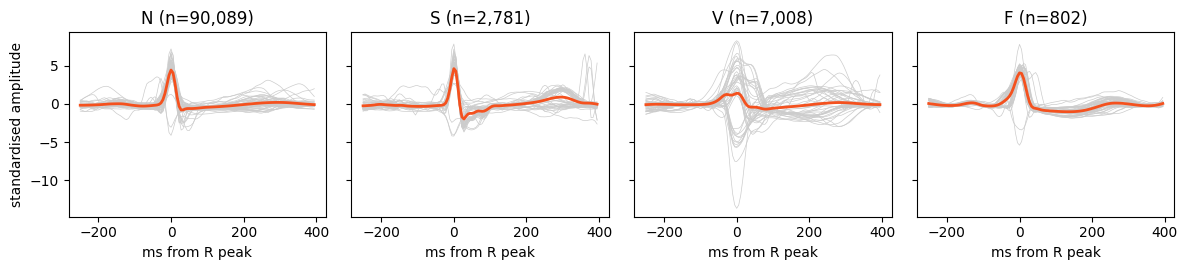

In [6]:
tab = pd.crosstab(pd.Series(groups, name="subject"), pd.Series(np.array(CLASSES)[y], name="class"))[CLASSES]
print("beats per subject: median", int(tab.sum(axis=1).median()),
      "| min", int(tab.sum(axis=1).min()), "| max", int(tab.sum(axis=1).max()))
for c in ["S", "V", "F"]:
    top = tab[c].sort_values(ascending=False)
    print(f"{c}: {int((top > 0).sum())} of 43 subjects have any; "
          f"top-2 subjects ({', '.join(top.index[:2])}) hold {100 * top.iloc[:2].sum() / top.sum():.0f}%")

fig, axes = plt.subplots(1, 4, figsize=(12, 2.8), sharey=True)
t_ms = (np.arange(X.shape[1]) * STEP - PRE) / 360 * 1000
for k, ax in enumerate(axes):
    beats = X[y == k, :, 0]
    ax.plot(t_ms, beats[:: max(1, len(beats) // 40)].T, color="0.8", lw=0.5)   # ~40 example beats
    ax.plot(t_ms, beats.mean(axis=0), color="#F4511E", lw=2)
    ax.set_title(f"{CLASSES[k]} (n={len(beats):,})")
    ax.set_xlabel("ms from R peak")
axes[0].set_ylabel("standardised amplitude")
plt.tight_layout()
plt.show()

## 4. 兩種切法

兩種切法都分成 3 折（每次 2/3 訓練、1/3 測試），差別只在「打散的單位」：

- **切法 A：隨機切心跳**（`StratifiedKFold`）：所有心跳打散，各類別比例在每折相同。同一個人的心跳會同時出現在訓練與測試。
- **切法 B：依受試者切**（`StratifiedGroupKFold`，`groups` = 受試者）：同一個人的所有心跳只會在同一折。它是第 11 章分組 K-fold 的變形，會盡量讓各折的類別比例接近。

先確認兩種切法下，測試集裡的人有沒有在訓練集出現過：

In [7]:
splits = {
    "A: random beats": list(StratifiedKFold(3, shuffle=True, random_state=RS).split(X, y)),
    "B: by subject": list(StratifiedGroupKFold(3, shuffle=True, random_state=RS).split(X, y, groups)),
}
for name, folds in splits.items():
    for i, (tr, te) in enumerate(folds):
        assert len(set(tr) & set(te)) == 0 and len(tr) + len(te) == len(y)
        shared = set(groups[tr]) & set(groups[te])
        if name.startswith("B"):
            assert not shared                      # no subject on both sides
        print(f"{name} fold {i + 1}: test beats {len(te):,} from {len(set(groups[te]))} subjects; "
              f"subjects also in training: {len(shared)}; test class counts {np.bincount(y[te], minlength=4)}")

A: random beats fold 1: test beats 33,560 from 43 subjects; subjects also in training: 43; test class counts [30030   927  2336   267]
A: random beats fold 2: test beats 33,560 from 43 subjects; subjects also in training: 43; test class counts [30030   927  2336   267]
A: random beats fold 3: test beats 33,560 from 43 subjects; subjects also in training: 43; test class counts [30029   927  2336   268]
B: by subject fold 1: test beats 33,421 from 15 subjects; subjects also in training: 0; test class counts [29498  1463  2072   388]
B: by subject fold 2: test beats 36,285 from 15 subjects; subjects also in training: 0; test class counts [33158   853  2247    27]


B: by subject fold 3: test beats 30,974 from 13 subjects; subjects also in training: 0; test class counts [27433   465  2689   387]


切法 A 的每一折，測試集的 43 個人**全部**也在訓練集裡；切法 B 則沒有任何一個人重疊。也注意切法 B 各折的類別數差很多：F 類主要集中在少數人身上，某一折可能只分到幾十個。

## 5. 一維卷積網路（1D-CNN）

和第 12 章的 CNN 幾乎一樣，只是濾鏡從 3×3 的方格變成**沿時間軸滑動的一小段**（`Conv1D`）。三層卷積的濾鏡長度分別是 7、5、5 個點（180 Hz 下約 39、28、28 毫秒），`GlobalAveragePooling1D` 把每個濾鏡在整個心跳上的反應取平均，最後 `Dense(4, softmax)` 輸出四類的機率。

**處理不平衡**：在**切好之後**，只對訓練集的 N 類隨機抽 8,000 個（其他類全留），測試集完全不動，保持真實比例。若先抽樣再切，等於讓抽樣決定了誰當考題，也是一種洩漏的來源。

In [8]:
N_KEEP = 8000          # normal beats kept in each training set (after splitting)
EPOCHS = 12


def build_model():
    return keras.Sequential([
        keras.Input(shape=(X.shape[1], 1)),
        keras.layers.Conv1D(16, 7, padding="same", activation="relu"),   # 16 filters, 7 points long
        keras.layers.MaxPooling1D(2),
        keras.layers.Conv1D(32, 5, padding="same", activation="relu"),
        keras.layers.MaxPooling1D(2),
        keras.layers.Conv1D(32, 5, padding="same", activation="relu"),
        keras.layers.GlobalAveragePooling1D(),                           # average over time
        keras.layers.Dense(4, activation="softmax"),
    ])


def run_fold(tr, te, seed=RS):
    rng = np.random.default_rng(seed)
    tr_n = tr[y[tr] == 0]
    keep = np.concatenate([rng.choice(tr_n, min(N_KEEP, len(tr_n)), replace=False), tr[y[tr] != 0]])
    keras.utils.set_random_seed(seed)
    model = build_model()
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=3e-3), loss="sparse_categorical_crossentropy")
    t = time.time()
    model.fit(X[keep], y[keep], epochs=EPOCHS, batch_size=128, verbose=0)
    pred = model.predict(X[te], batch_size=2048, verbose=0).argmax(axis=1)
    sens = recall_score(y[te], pred, labels=[0, 1, 2, 3], average=None, zero_division=np.nan)
    return {"acc": np.mean(pred == y[te]),
            "macro_f1": f1_score(y[te], pred, labels=[0, 1, 2, 3], average="macro"),
            **{f"sens_{c}": s for c, s in zip(CLASSES, sens)},
            "baseline_acc": np.mean(y[te] == 0),    # always predict N
            "n_train": len(keep), "train_s": time.time() - t, "pred": pred, "true": y[te]}


if keras is not None:
    build_model().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 117, 16)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 58, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 58, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 29, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 29, 32)         │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,004 (31.27 KB)

 Trainable params: 8,004 (31.27 KB)

 Non-trainable params: 0 (0.00 B)

### 5.1 第 1 折：兩種切法各訓練一次

同一個模型、同樣的超參數、同樣的種子，只換切法。本機 CPU 每個模型約 20 秒。

In [9]:
results = {name: [] for name in splits}
if keras is not None:
    for name, folds in splits.items():
        results[name].append(run_fold(*folds[0]))
        r = results[name][0]
        print(f"{name}: trained on {r['n_train']:,} beats in {r['train_s']:.1f} s")
    show = ["acc", "baseline_acc", "macro_f1"] + [f"sens_{c}" for c in CLASSES]
    print(pd.DataFrame({k: v[0] for k, v in results.items()}).loc[show].astype(float).round(3))
else:
    print("Skipped: Keras is not available.")

A: random beats: trained on 15,061 beats in 18.6 s


B: by subject: trained on 14,668 beats in 18.5 s
              A: random beats  B: by subject
acc                     0.924          0.873
baseline_acc            0.895          0.883
macro_f1                0.712          0.406
sens_N                  0.928          0.923
sens_S                  0.789          0.000
sens_V                  0.943          0.944
sens_F                  0.757          0.000


`baseline_acc` 是「全部猜 N」的多數類基準。看準確率之外，請特別看 **S 與 F 的敏感度**：同一個模型，換成依受試者切之後，這兩類的表現落差最大。

下面的混淆矩陣把差別畫出來（列＝真實類別，欄＝預測；每列已換算成比例）：

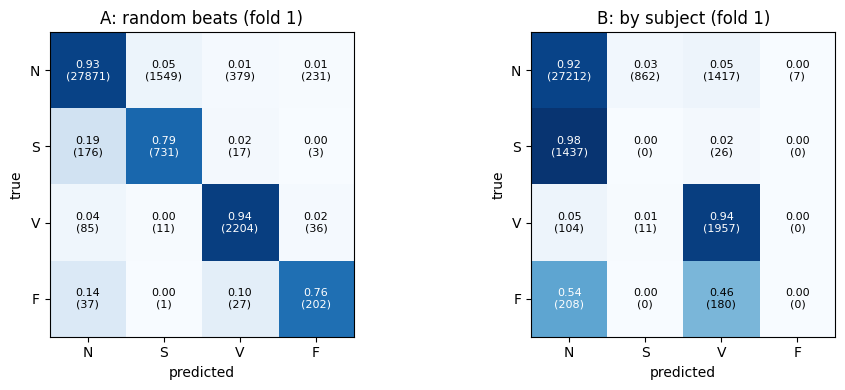

In [10]:
if keras is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, (name, res) in zip(axes, results.items()):
        cm = confusion_matrix(res[0]["true"], res[0]["pred"], labels=[0, 1, 2, 3])
        cm_row = cm / cm.sum(axis=1, keepdims=True)
        ax.imshow(cm_row, cmap="Blues", vmin=0, vmax=1)
        for i in range(4):
            for j in range(4):
                ax.text(j, i, f"{cm_row[i, j]:.2f}\n({cm[i, j]})", ha="center", va="center", fontsize=8,
                        color="white" if cm_row[i, j] > 0.5 else "black")
        ax.set_xticks(range(4), CLASSES)
        ax.set_yticks(range(4), CLASSES)
        ax.set_xlabel("predicted")
        ax.set_ylabel("true")
        ax.set_title(f"{name} (fold 1)")
    plt.tight_layout()
    plt.show()

### 5.2 重複另外兩折（建議開 GPU，可跳過）

只看一折可能是運氣。這一格把兩種切法的第 2、3 折也跑完（再訓練 4 個模型），報告 3 折的平均與範圍。Colab 免費 CPU 上可能要數分鐘；跳過的話，下一格只會用第 1 折。

In [11]:
if keras is not None:
    for name, folds in splits.items():
        for tr, te in folds[1:]:
            results[name].append(run_fold(tr, te))
            print(f"{name} fold {len(results[name])}: done in {results[name][-1]['train_s']:.1f} s")

A: random beats fold 2: done in 18.1 s


A: random beats fold 3: done in 18.6 s


B: by subject fold 2: done in 20.1 s


B: by subject fold 3: done in 19.8 s


In [12]:
if keras is not None:
    import json
    rows = []
    for name, res in results.items():
        for i, r in enumerate(res):
            rows.append({"split": name, "fold": i + 1, **{k: v for k, v in r.items() if k not in ("pred", "true")}})
    df = pd.DataFrame(rows)
    cols = ["acc", "baseline_acc", "macro_f1", "sens_N", "sens_S", "sens_V", "sens_F"]
    print("per fold:")
    print(df[["split", "fold"] + cols].round(3).to_string(index=False))
    print("\nmean [min, max] over folds:")
    summary = df.groupby("split")[cols].agg(["mean", "min", "max"])
    for name in results:
        print(name + ": " + " | ".join(
            f"{c} {summary.loc[name, (c, 'mean')]:.3f} [{summary.loc[name, (c, 'min')]:.3f}, "
            f"{summary.loc[name, (c, 'max')]:.3f}]" for c in cols))
    # machine-readable line used by scripts/figs_ch14.py to draw the chapter figure
    print("RESULTS_JSON", json.dumps(df[["split", "fold"] + cols].round(4).to_dict(orient="records")))

per fold:
          split  fold   acc  baseline_acc  macro_f1  sens_N  sens_S  sens_V  sens_F
A: random beats     1 0.924         0.895     0.712   0.928   0.789   0.943   0.757
A: random beats     2 0.954         0.895     0.782   0.963   0.746   0.957   0.652
A: random beats     3 0.967         0.895     0.796   0.979   0.657   0.969   0.623
  B: by subject     1 0.873         0.883     0.406   0.923   0.000   0.944   0.000
  B: by subject     2 0.938         0.914     0.450   0.970   0.007   0.838   0.148
  B: by subject     3 0.742         0.886     0.364   0.738   0.282   0.971   0.000

mean [min, max] over folds:
A: random beats: acc 0.948 [0.924, 0.967] | baseline_acc 0.895 [0.895, 0.895] | macro_f1 0.763 [0.712, 0.796] | sens_N 0.957 [0.928, 0.979] | sens_S 0.731 [0.657, 0.789] | sens_V 0.956 [0.943, 0.969] | sens_F 0.677 [0.623, 0.757]
B: by subject: acc 0.851 [0.742, 0.938] | baseline_acc 0.894 [0.883, 0.914] | macro_f1 0.407 [0.364, 0.450] | sens_N 0.877 [0.738, 0.970] | sen

## 6. 解讀

- **切法 A（隨機切心跳）看起來很好**：測試集裡每個人都在訓練集出現過，模型只要「認得這個人的心跳長相」就能答對，不需要學會「什麼樣的波形是上心室早期收縮」。
- **切法 B（依受試者切）比較接近部署時的情境**（但仍是同一個資料庫，不等於外部驗證）：模型要面對從沒看過的病人。S 與 F 的敏感度通常大幅下降：S 類（例如心房早期收縮）的波形本身和正常心跳很像，主要靠「來得太早」（RR 間期）辨認，而我們的切窗只有單一心跳的形狀；F 類集中在少數人，換人就幾乎認不出來。
- **準確率會騙人**：N 類占近九成，「全部猜 N」就有約 0.9 的準確率。依受試者切時，模型的準確率可能接近、甚至低於這個基準；要看 macro-F1 與各類別敏感度才看得出問題。
- 這些數字只來自 MIT-BIH 一個資料庫、44 段紀錄、單一導程，3 折之間的差距很大，請當成「方向」而不是精確估計。真正要回答「換一家醫院還準不準」，需要在另一個資料庫做外部驗證。

In [13]:
print(f"total notebook time: {time.time() - T_START:.1f} s "
      f"(download + reading {T_LOAD:.1f} s, beat preparation {T_PREP:.1f} s)")

total notebook time: 125.2 s (download + reading 1.7 s, beat preparation 1.5 s)


## 7. 動手試試

1. **加上類別權重**：在 `model.fit` 加入 `class_weight`（例如 `{c: len(keep) / (4 * np.sum(y[keep] == c)) for c in range(4)}`），看 S、F 的敏感度與 N 的敏感度如何交換。
2. **換成循環神經網路（GRU）**：把 `build_model` 裡的卷積層換成下面這段，比較兩種切法下的差距是否仍然存在（CPU 上會慢很多，建議開 GPU）：
   ```python
   keras.layers.Conv1D(16, 7, padding="same", activation="relu"),
   keras.layers.MaxPooling1D(2),
   keras.layers.GRU(32),               # reads the sequence step by step, keeps a hidden state
   keras.layers.Dense(4, activation="softmax"),
   ```
3. **加長切窗**：把 `PRE, POST` 改成 `270, 270`（R 峰前後各 0.75 秒，通常會包含前後一個心跳），再把 `STEP` 改成 3。模型多看到「前一個心跳在哪裡」之後，依受試者切的 S 類敏感度有沒有改善？
4. **只分 N 與 V 兩類**：把 S、F 的心跳拿掉，重新比較兩種切法。差距變大還是變小？為什麼？

## 參考資料

- Moody GB, Mark RG. The impact of the MIT-BIH Arrhythmia Database. *IEEE Eng Med Biol Mag* 2001;20(3):45–50.
- Goldberger AL, et al. PhysioBank, PhysioToolkit, and PhysioNet. *Circulation* 2000;101(23):e215–e220.
- MIT-BIH Arrhythmia Database v1.0.0：<https://physionet.org/content/mitdb/1.0.0/>（ODC-By v1.0）